<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Practica_4_%C3%81rboles_de_Decisi%C3%B3n_Lending_Club.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
prestamos_df = pd.read_csv('lending_club_2007_2011_6_states (2).csv')
prestamos_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [2]:
prestamos_df["grade_code"] = prestamos_df["grade"].astype("category").cat.codes
prestamos_df["purpose_code"] = prestamos_df["purpose"].astype("category").cat.codes
prestamos_df["addr_state_code"] = prestamos_df["addr_state"].astype("category").cat.codes
prestamos_df["home_ownership_code"] = prestamos_df["home_ownership"].astype("category").cat.codes
prestamos_df["repaid"] = prestamos_df["loan_status"].apply(
    lambda x: 1 if x == "Fully Paid" else 0
)

In [3]:
X = prestamos_df[['funded_amnt', "int_rate", "grade_code", 'purpose_code', 'addr_state_code',
                  'home_ownership_code', 'annual_inc', 'dti', 'revol_util',
                  'pub_rec_bankruptcies']]
y = prestamos_df["repaid"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.4, stratify=y )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11944, 10), (7964, 10), (11944,), (7964,))

In [5]:
from numpy.random import RandomState
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
print("precision del clasificador ne fase de entrenamiento", tree_model.score(X_train, y_train))


precision del clasificador ne fase de entrenamiento 0.8545713328868051


In [6]:
y_pred = tree_model.predict(X_test)
print("\nReporte de metricas del clasificado de arboles de desicion: \n",
      classification_report(y_test, y_pred, target_names=["No pagado", "Pagado"]))
print(f'\nMatriz de confusion de arboles de desicion:\n', confusion_matrix(y_test, y_pred))


Reporte de metricas del clasificado de arboles de desicion: 
               precision    recall  f1-score   support

   No pagado       0.31      0.01      0.02      1177
      Pagado       0.85      0.99      0.92      6787

    accuracy                           0.85      7964
   macro avg       0.58      0.50      0.47      7964
weighted avg       0.77      0.85      0.79      7964


Matriz de confusion de arboles de desicion:
 [[  15 1162]
 [  34 6753]]


In [7]:
tree_model2 = DecisionTreeClassifier(criterion='gini', max_depth=5, class_weight='balanced', random_state=42, )
tree_model2.fit(X_train, y_train)
y_pred2 = tree_model2.predict(X_test)
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
      classification_report(y_test, y_pred2, target_names=["No Pagado", "Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred2))



Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.21      0.62      0.32      1177
      Pagado       0.90      0.61      0.73      6787

    accuracy                           0.61      7964
   macro avg       0.56      0.61      0.52      7964
weighted avg       0.80      0.61      0.67      7964


 Matriz de Confusión:
[[ 727  450]
 [2667 4120]]


In [8]:
tree_model3 = DecisionTreeClassifier(criterion='gini', max_depth=7, class_weight='balanced', random_state=42)
tree_model3.fit(X_train, y_train)
y_pred3 = tree_model3.predict(X_test)
print("\nReporte de métricas del clasificador de Arbolesde Decisión: \n",
      classification_report(y_test, y_pred3, target_names=["No Pagado","Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred3))


Reporte de métricas del clasificador de Arbolesde Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.21      0.67      0.31      1177
      Pagado       0.91      0.55      0.69      6787

    accuracy                           0.57      7964
   macro avg       0.56      0.61      0.50      7964
weighted avg       0.80      0.57      0.63      7964


 Matriz de Confusión:
[[ 784  393]
 [3034 3753]]


In [9]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt
model_columns = ['funded_amnt',"int_rate","grade_code",'purpose_code','addr_state_code',
                 'home_ownership_code','annual_inc','dti','revol_util',
                 'pub_rec_bankruptcies']
print(export_text(tree_model3, feature_names=model_columns))



|--- int_rate <= 11.61
|   |--- int_rate <= 8.43
|   |   |--- annual_inc <= 58272.00
|   |   |   |--- revol_util <= 20.45
|   |   |   |   |--- revol_util <= 5.35
|   |   |   |   |   |--- annual_inc <= 34500.00
|   |   |   |   |   |   |--- annual_inc <= 26296.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- annual_inc >  26296.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- annual_inc >  34500.00
|   |   |   |   |   |   |--- annual_inc <= 54900.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- annual_inc >  54900.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- revol_util >  5.35
|   |   |   |   |   |--- dti <= 11.82
|   |   |   |   |   |   |--- dti <= 11.63
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- dti >  11.63
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- dti >  11.82
|   |   |   |   |   |   |--- funded_amnt <= 4150.00
|   |   |   |   |   |   |   |-

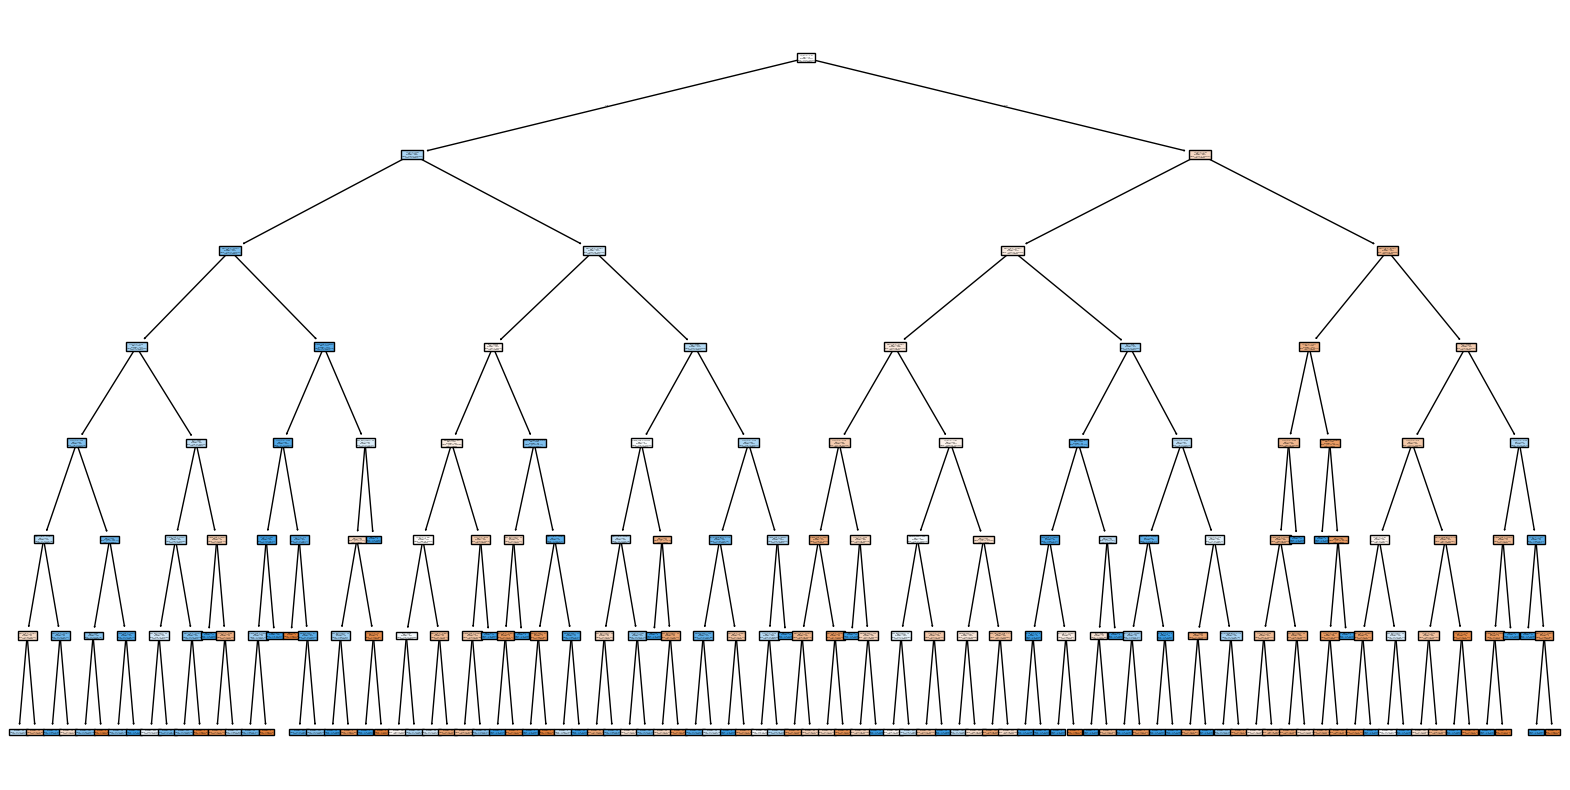

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model3, feature_names=model_columns, class_names=["Pagado", "No pagado"], filled=True)
plt.show()

In [13]:
importancia_caracteristicas = pd.DataFrame({
    'Caracteristica': model_columns,
    'Importancia': tree_model3.feature_importances_
}).sort_values(by='Importancia', ascending=False)
print("\nImportancia de las características:")
print(importancia_caracteristicas)


Importancia de las características:
         Caracteristica   Importancia
1              int_rate  4.668801e-01
6            annual_inc  1.764909e-01
8            revol_util  1.157532e-01
7                   dti  6.718836e-02
0           funded_amnt  6.020113e-02
4       addr_state_code  4.218611e-02
3          purpose_code  4.113569e-02
9  pub_rec_bankruptcies  1.769875e-02
5   home_ownership_code  1.246583e-02
2            grade_code  6.807287e-17


In [14]:
import plotly.express as px
fig4 = px.bar(importancia_caracteristicas, x="Caracteristica", y="Importancia",
              title="Importancia de las Características",
              text_auto="3.F", color="Caracteristica")
fig4.update_layout(width=800, height=600)
fig4.show()

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced'],
    'ccp_alpha': [0.0, 0.001, 0.01]
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='recall_macro', # o 'f2' si te interesa más los impagos
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Mejores parámetros: {'ccp_alpha': 0.001, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [16]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nReporte de Clasificación (modelo optimizadopara detectar impagos):\n")
print(classification_report(y_test, y_pred))
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))


Reporte de Clasificación (modelo optimizadopara detectar impagos):

              precision    recall  f1-score   support

           0       0.22      0.63      0.32      1177
           1       0.90      0.60      0.72      6787

    accuracy                           0.61      7964
   macro avg       0.56      0.62      0.52      7964
weighted avg       0.80      0.61      0.66      7964

Matriz de Confusión:
[[ 741  436]
 [2702 4085]]
